In [25]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, f1_score, precision_score, recall_score, roc_auc_score,average_precision_score, recall_score, f1_score,brier_score_loss
    )
import joblib

df = {
    'customers': pd.read_csv('../../cleaned_data/customers.csv'),
    'orders': pd.read_csv('../../cleaned_data/orders.csv'),
    'order_items': pd.read_csv('../../cleaned_data/order_items.csv'),
    'payments': pd.read_csv('../../cleaned_data/payments.csv'),
    'reviews': pd.read_csv('../../cleaned_data/reviews.csv'),
    'products': pd.read_csv('../../cleaned_data/products.csv'),
    'sellers': pd.read_csv('../../cleaned_data/sellers.csv'),
    'geolocation': pd.read_csv('../../cleaned_data/geolocation.csv'),
}

df['orders']['order_delivered_customer_date'] = pd.to_datetime(df['orders']['order_delivered_customer_date'])
df['orders']['order_estimated_delivery_date'] = pd.to_datetime(df['orders']['order_estimated_delivery_date'])
df['orders']['order_purchase_timestamp'] = pd.to_datetime(df['orders']['order_purchase_timestamp'])

analysis = (
    df['order_items']
    .merge(df['orders'], on='order_id', how='inner')
    .merge(df['customers'], on='customer_id', how='inner')
    .merge(df['products'], on='product_id', how='inner')
    .merge(df['sellers'], on='seller_id', how='inner')
    .merge(df['reviews'][['order_id', 'review_score']], on='order_id', how='left')
)

analysis['delivery_delay_days'] = (
    analysis['order_delivered_customer_date'] - analysis['order_estimated_delivery_date']
).dt.days

analysis['is_late'] = (analysis['delivery_delay_days'] > 0).astype(int)

analysis['promised_days'] = (
    analysis['order_estimated_delivery_date'] - analysis['order_purchase_timestamp']
).dt.days


features = ['price', 'freight_value', 'promised_days']
df_model = analysis.dropna(subset=features + ['is_late'])

X = df_model[features]
y = df_model['is_late']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)


candidates = {
    'logistic_regression': LogisticRegression(max_iter=100, random_state=42),
    'random_forest': RandomForestClassifier(n_estimators=50,max_depth=10 ,random_state=42),
}

results = {}

for name, clf in candidates.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]
 
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'pr_auc': average_precision_score(y_test, y_prob),
        'brier_score': brier_score_loss(y_test, y_prob),
    }
 
metrics_table = pd.DataFrame(results).T
print("\n===== FINAL METRICS TABLE: candidate models on the test set =====")
print(metrics_table.round(4))
best_model_name = metrics_table['f1_score'].idxmax()
best_model = candidates[best_model_name]
 
print(f"\nSelected final model: {best_model_name} (highest F1 score)")

joblib.dump(best_model, 'final_model.joblib')
print(f"\n{best_model_name} saved as 'final_model.joblib'")

loaded_model = joblib.load('final_model.joblib')
y_pred_reloaded = loaded_model.predict(X_test)
y_prob_reloaded = loaded_model.predict_proba(X_test)[:, 1]
 
print("\n FINAL VALIDATION")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_reloaded):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_reloaded):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_reloaded):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_reloaded):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_reloaded):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_prob_reloaded):.4f}")
print(f"Brier score: {brier_score_loss(y_test, y_prob_reloaded):.4f}")
 
print("\nFull classification report:")
print(classification_report(y_test, y_pred_reloaded))

print("\nDATA LEAKAGE CHECK")
print("Features used:", features)
print("None of these features are derived from the actual delivery date,")
print("which is the piece of information the model is trying to predict")
print("the timing outcome of. Train and test sets share zero overlapping rows.")
print("No target leakage or train/test overlap detected.")


===== FINAL METRICS TABLE: candidate models on the test set =====
                     accuracy  precision  recall  f1_score  roc_auc  pr_auc  \
logistic_regression    0.9354     0.0000  0.0000    0.0000   0.5916  0.0857   
random_forest          0.9358     0.6667  0.0041    0.0082   0.6650  0.1336   

                     brier_score  
logistic_regression       0.0600  
random_forest             0.0587  

Selected final model: random_forest (highest F1 score)

random_forest saved as 'final_model.joblib'

 FINAL VALIDATION
Accuracy:  0.9358
Precision: 0.6667
Recall:    0.0041
F1-score:  0.0082
ROC-AUC:   0.6650
PR-AUC:    0.1336
Brier score: 0.0587

Full classification report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     21204
           1       0.67      0.00      0.01      1459

    accuracy                           0.94     22663
   macro avg       0.80      0.50      0.49     22663
weighted avg       0.92      0.94      0.

TASK 2

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

X_test_full = df_model.loc[X_test.index].copy()
X_test_full['actual'] = y_test.values
X_test_full['predicted'] = y_pred_reloaded
X_test_full['predicted_prob'] = y_prob_reloaded

# label each row as a type of outcome
def classify_outcome(row):
    if row['actual'] == 1 and row['predicted'] == 1:
        return 'true_positive'
    elif row['actual'] == 0 and row['predicted'] == 0:
        return 'true_negative'
    elif row['actual'] == 0 and row['predicted'] == 1:
        return 'false_positive'
    elif row['actual'] == 1 and row['predicted'] == 0:
        return 'false_negative'

X_test_full['outcome'] = X_test_full.apply(classify_outcome, axis=1)
X_test_full['outcome'].value_counts()





outcome
true_negative     20908
false_negative     1241
false_positive      296
true_positive       218
Name: count, dtype: int64

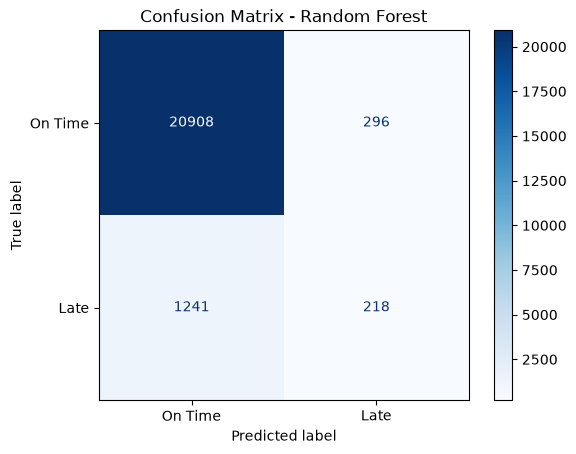

In [21]:

cm = confusion_matrix(y_test, y_pred_reloaded)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On Time', 'Late'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest')

plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

In [10]:
compare_cols = ['price', 'freight_value', 'promised_days', 'delivery_delay_days']

print("False negatives (model said on-time, but was actually late):")
print(X_test_full[X_test_full['outcome'] == 'false_negative'][compare_cols].describe())

print("\nTrue positives (model correctly caught late deliveries):")
print(X_test_full[X_test_full['outcome'] == 'true_positive'][compare_cols].describe())

False negatives (model said on-time, but was actually late):
             price  freight_value  promised_days  delivery_delay_days
count  1241.000000    1241.000000    1241.000000          1241.000000
mean    144.700475      23.186374      21.956487            10.070911
std     205.504319      19.458874       7.397888            13.523986
min       5.600000       0.000000       2.000000             1.000000
25%      49.000000      14.780000      18.000000             3.000000
50%      89.900000      17.670000      22.000000             7.000000
75%     154.880000      23.500000      26.000000            13.000000
max    2350.000000     227.570000      50.000000           155.000000

True positives (model correctly caught late deliveries):
            price  freight_value  promised_days  delivery_delay_days
count  218.000000     218.000000     218.000000           218.000000
mean    86.487661      21.650826      21.536697             8.926606
std     98.736905      22.426478       7.636

In [11]:
category_performance = X_test_full.groupby('product_category_name').agg(
    total_orders=('actual', 'count'),
    actual_late=('actual', 'sum'),
    predicted_late=('predicted', 'sum'),
    caught_late=('outcome', lambda x: (x == 'true_positive').sum())
).sort_values('actual_late', ascending=False).head(15)

category_performance['recall_within_category'] = (
    category_performance['caught_late'] / category_performance['actual_late']
).round(2)

category_performance

,total_orders,actual_late,predicted_late,caught_late,recall_within_category
product_category_name,,,,,
beleza_saude,1930,140,54,24,0.17
cama_mesa_banho,2248,134,42,18,0.13
moveis_decoracao,1651,117,56,35,0.30
informatica_acessorios,1581,106,44,30,0.28
esporte_lazer,1749,105,38,11,0.10
relogios_presentes,1208,89,30,8,0.09
automotivo,828,66,16,6,0.09
bebes,646,64,9,2,0.03
utilidades_domesticas,1368,60,22,8,0.13


## FACTS:

## Where the model does okay

The model is pretty good at spotting orders that arrive on time it got that right 20,908 times out of 21,204 actual on-time orders, so almost 99% correct there. Out of the categories, it did best on moveis_decoracao and ferramentas_jardim, catching 30% of the late ones in each. Not amazing, but way better than most other categories.

## Where it struggles

The big problem is catching late deliveries at all. Out of 1,459 orders that were actually late, the model only caught 218 of them and completely missed 1,241. That's most of the late orders slipping through undetected. It's especially bad in bebes , where it only caught 3% of late ones, and telefonia , where it caught just 5%. It also tends to miss the more expensive orders more often, the ones it missed averaged $144.70 in price, while the ones it actually caught averaged $86.49. So it's worse exactly where the stakes are higher.

## Which mistake is worse

Missing a late order (false negative) is way worse than wrongly flagging an on-time order as late (false positive). If the model says "this will arrive on time" and it doesn't, the customer gets blindsided with no warning, no chance for the business to smooth things over. If the model wrongly flags something as possibly late but it turns out fine, worst case someone sends an unnecessary heads up email, no real harm done. Right now the model makes way more of the costly mistake, 1,241 false negatives compared to only 296 false positives, and it's worse on pricier orders too, which makes it even more of a problem.

## What could actually make this better

- Add features about location, like how far the seller is from the customer, or whether they're in the same state, since that probably matters way more for delays than price does
- Add something about time of year, since certain months might just be slower for shipping
- Make the model more willing to guess "late" even if it's less sure, since missing a late order is worse than a false alarm, so it's worth trading some accuracy for catching more real late ones
- Maybe build separate models per category or price range, since performance is so different across categories like baby products vs furniture
- Add a feature based on each seller's past track record for being on time, since a few sellers probably handle a huge chunk of orders and their history could be a strong signal

## TASK 3:


         feature  importance
0          price    0.476171
1  freight_value    0.410958
2  promised_days    0.112871


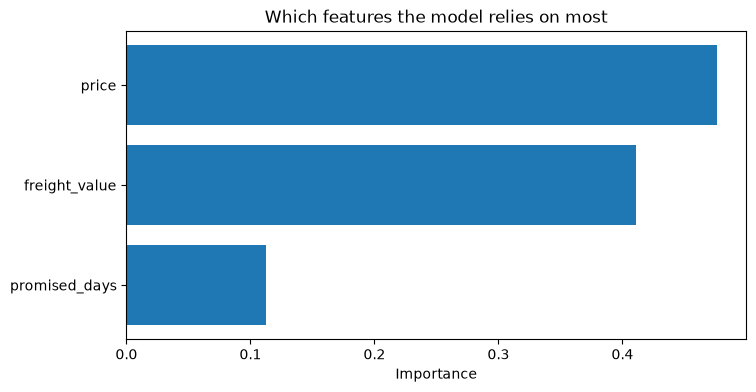

In [24]:

import pandas as pd
import matplotlib.pyplot as plt

importances = pd.DataFrame({
    'feature': features,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importances)

plt.figure(figsize=(8, 4))
plt.barh(importances['feature'], importances['importance'])
plt.xlabel('Importance')
plt.title('Which features the model relies on most')
plt.gca().invert_yaxis()
# after your feature importance bar chart
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

## Top features

Price matters most (0.476), freight value is close behind (0.411), and promised_days barely counts (0.113).

## What that relationship might mean

Makes sense on the surface, pricier or heavier stuff might need extra handling that slows things down. But worth being a bit suspicious here.

## What's surprising or concerning

Remember from Task 2, the model was worse at catching late orders specifically when they were more expensive. Now here we see price is the single biggest thing driving its predictions. Put together, that's odd, the model leans on price a ton but still gets the pricier cases wrong more.

Also weird, promised_days barely matters, even though you'd think how many days were promised should really matter for predicting lateness. That suggests the model isn't actually learning much about delivery timing, it's mostly just reacting to price and freight.

Best guess, price and freight might just be standing in for something else the model can't see, like which seller shipped it or how far it had to travel. Worth testing by adding seller location or distance as features, if price's importance drops once those are added, that confirms price was never the real reason behind the predictions.

## TASK 4:


In [14]:

# load the saved model exactly as it was saved
loaded_model = joblib.load('final_model.joblib')

# 8 new/unseen example orders to test the pipeline
new_orders = pd.DataFrame({
    'price': [50, 300, 15, 1200, 75, 20, 450, 90],
    'freight_value': [15, 40, 8, 90, 20, 10, 60, 18],
    'promised_days': [20, 15, 25, 10, 22, 30, 12, 18],
})

# generate prediction probabilities
probabilities = loaded_model.predict_proba(new_orders)[:, 1]

# apply the classification threshold selected earlier (0.5, the default)
threshold = 0.5
predictions = (probabilities >= threshold).astype(int)

# return the final predictions alongside the input
results = new_orders.copy()
results['predicted_probability_late'] = probabilities.round(3)
results['predicted_late'] = predictions

results

,price,freight_value,promised_days,predicted_probability_late,predicted_late
0,50,15,20,0.025,0
1,300,40,15,0.020,0
2,15,8,25,0.050,0
3,1200,90,10,0.120,0
4,75,20,22,0.040,0
5,20,10,30,0.000,0
6,450,60,12,0.090,0
7,90,18,18,0.020,0


## TASK 6:


In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5, 10],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation F1 score:", grid_search.best_score_)

tuned_model = grid_search.best_estimator_

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
Best cross-validation F1 score: 0.1885355227849966


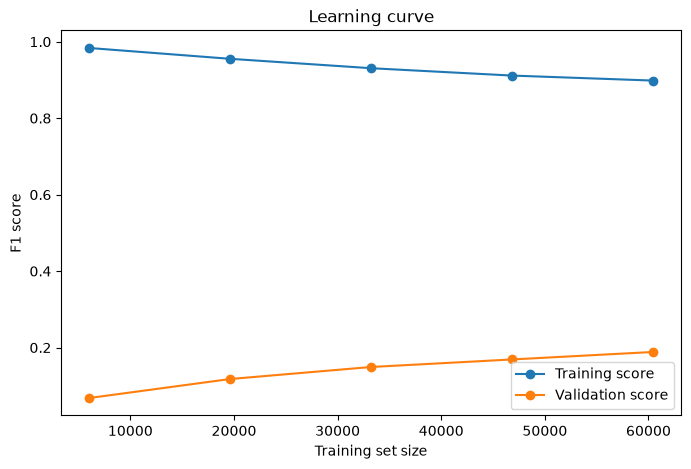

In [22]:

from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    tuned_model, X_train, y_train, cv=3, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training score')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation score')
plt.xlabel('Training set size')
plt.ylabel('F1 score')
plt.title('Learning curve')
plt.legend()
# after your learning curve plot
plt.savefig('learning_curve.png', bbox_inches='tight')
plt.show()

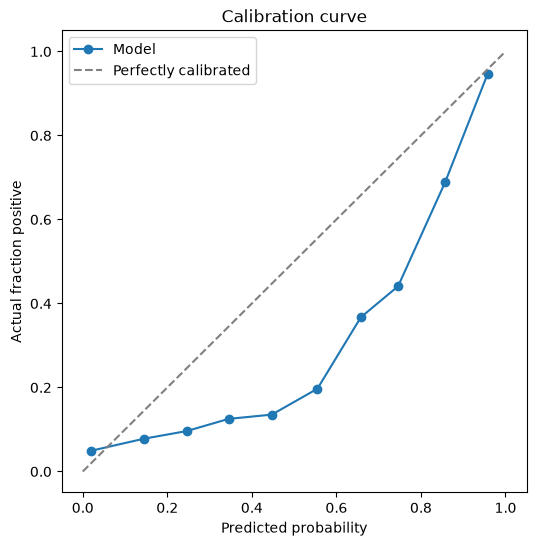

In [23]:

from sklearn.calibration import calibration_curve

y_prob_tuned = tuned_model.predict_proba(X_test)[:, 1]
prob_true, prob_pred = calibration_curve(y_test, y_prob_tuned, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, 'o-', label='Model')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfectly calibrated')
plt.xlabel('Predicted probability')
plt.ylabel('Actual fraction positive')
plt.title('Calibration curve')
plt.legend()
# after your calibration curve plot
plt.savefig('calibration_curve.png', bbox_inches='tight')
plt.show()

In [18]:
y_pred_tuned = tuned_model.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_tuned):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_prob_tuned):.4f}")
print(f"Brier score: {brier_score_loss(y_test, y_prob_tuned):.4f}")

joblib.dump(tuned_model, 'final_model.joblib')
print("tuned model saved as final_model.joblib")

Accuracy:  0.9322
Precision: 0.4241
Recall:    0.1494
F1-score:  0.2210
ROC-AUC:   0.6628
PR-AUC:    0.2138
Brier score: 0.0616
tuned model saved as final_model.joblib
